# Least Squares Problems and the QR Factorization

## Least Squares Problems

Given $A$ a tall, skinny matrix, we normally do not have a solution to $Ax=b$.

Instead, we attempt to minimize $\|Ax-b\|_2$ (a least-squares problem).

From intro to Lin AlgL if $A$ has independent columns, then:

1) $\min\|Ax-b\|_2$ has a unique solution

2) The solution satisfies the 'normal equations' $A^TAx=A^tb$

3) $A^TA$ is invertible # it is also pos def

Often in applications: several columns of our matrix $A$ are 'almost' dependent. In this case, $A^TA$ is a very ill-conditioned matrix. Therefore the computed $x$ is very innacurate.



In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [2]:
# least squares problem with known solution

A = np.random.randn(100,4)
A[:,3] = A[:,0]-A[:,1]+1e-10*np.random.randn(100) # almost row 1 minus row 2

x = np.array([1,1,1,0])

b = A.dot(x)

In [3]:
# using normal equation

xNormal = np.linalg.solve(A.T.dot(A), A.T.dot(b))

In [4]:
#using Numpy

xNumpy = np.linalg.lstsq(A,b, rcond=None)[0]

In [5]:
xNormal

array([-1.51705435e+07,  1.51705455e+07,  9.99930698e-01,  1.51705445e+07])

In [6]:
xNumpy

array([ 1.00000002e+00,  9.99999975e-01,  1.00000000e+00, -2.46081517e-08])

In [7]:
np.log10(np.linalg.cond(A.T.dot(A)))

16.105551595713305

## Getting around this issue: The QR factorization

$A_{m\times n} = Q_{m\times n}R_{n\times n}$

where $Q$ has orthonormal columns (so $Q^TQ = I_n$) abd $R$ is both upper triangular and invertible.

### The Gram - Schmidt Method

Factor $A = [a_1 | a_2 |\ldots |a_n] = [q_1|q_2|\ldots|q_n] R$, for upper triangular, nonsingular $R$

Step 1: compute euclidean norm of column 1

$r_{11} = \|a_1\|_2$, $q_1 = \frac{a_{1}}{r_{11}}$

step 2:

$r_{12} = q_1^Ta_2$, $\hat{a}_2 = a_2-(q_1^Ta_2)q_1$ # subtract projection of $a_2$ into $q_1$: we get an orthogonal vector!

$r_{22} = \|\hat{a}_2\|_2$, $q_2 = \hat{a}_2/r_{22}$

step 3: 

$r_{12} = q_1^Ta_3$, $r_{23} = q_2^Ta_3$

$\hat{a}_3 = a_3 -(q_1^Ta_3)q_1 -(q_2^Ta_3)q_2$

$r_{33} = \|\hat{a}_3\|_2$ $q_3, = \frac{\hat{a}_3}{r_{33}}$

step i:

$r[:i-1,i] = [q_1|\ldots|q_{i-1}]^Ta_i$

$\hat{a}_i = a_i - [q_1|\ldots |q_{i-1}] r[:i-1,i]$

$r{ii} = \|\hat{a}_i\|$

$q_i = \frac{\hat{a}_i}{r_{ii}}$



### QR implementation via Gram-Schmidt:

In [8]:
def my_qr1(A):
    m,n = A.shape
    Q = A.copy()
    R = np.zeros((n,n))
    
    for i in range(n):
        
        R[0:i,i] = Q[:,0:i].T.dot(Q[:,i])
        Q[:,i] = Q[:,i] - Q[:,0:i].dot(R[0:i,i])       
        R[i,i] = np.linalg.norm(Q[:,i])        
        Q[:,i] = Q[:,i] / R[i,i]
        
    return Q,R

In [9]:
# test my_qr function

A = np.random.randn(10,4)
Q,R = my_qr1(A)

# Q has orthonormal columns?

np.linalg.norm(Q.T.dot(Q)-np.eye(4))

In [10]:
R

array([[ 2.22477294, -0.10691928, -1.87060177, -0.39584235],
       [ 0.        ,  3.87087202,  1.39353557, -1.48115651],
       [ 0.        ,  0.        ,  2.80498497,  0.53099116],
       [ 0.        ,  0.        ,  0.        ,  3.46079136]])

In [11]:
np.linalg.norm(A-Q.dot(R)) # see if A and R are close to each other

3.152427400121712e-16

## Using the QR factorization to solve a least - squares problem

Recall our problem:

$\min \|Ax-b\|_2$, or  $A^TAx = A^T b$

we now have $A= QR$, thus our problem becomes:

$R^TQ^TQRx = R^TQ^Tb$. But $Q^TQ = I_n$, so we have $R^TRx = $R^TQ^Tb$. 

Using invertibility of $R$, we can write this as $Rx = Q^T b $ (upper triangular linear system) (solve in $O(n^2)$)

### Gram- Schmidt and Roundoff Errors

We get cancellation when we have near-parallel vectors. We can resolve it using **Reflectors**.

A reflector is a matrix of the form 

$Q = I_n-2uu^T$, with $\|u\|_2$ a unit vector. It reflects across the hyperplane normal to $u$
****

### QR factorization by Reflectors:



In [12]:
n = 5

x = np.random.randn(n)

In [13]:
# build reflector
u = x.copy()
tau = np.sign(u[0])*np.linalg.norm(u)
u[0] = u[0] + tau
u[1:n] = u[1:n]/tau
gamma = u[0]/tau
u[0] = 1

In [14]:
# apply reflector
x-gamma*u*(u.dot(x))

array([ 2.29771619, -0.54558912, -1.02913991, -0.52334793, -0.27880369])

In [15]:
def my_qr(A,how='reflectors',mode='economic'):
    'it factors a full-column rank A into Q (orthogonal) times R (upper triangular)'
    m,n = A.shape
    
    if how=='Gram-Schmidt':
        Q = A.copy()
        R = np.zeros((n,n))

        for i in range(n):
            R[0:i,i] = Q[:,0:i].T.dot(Q[:,i])
            Q[:,i] = Q[:,i] - Q[:,0:i].dot(R[0:i,i])
            R[i,i] = np.linalg.norm(Q[:,i])
            Q[:,i] = Q[:,i]/R[i,i]
        return Q,R
    elif how=='reflectors':
        R = A.copy()
        Q = np.eye(m)

        for j in range(n):

            # create reflector
            x = R[j:m,j].copy()
            tau = np.sign(x[0])*np.linalg.norm(x)
            x[0] = tau + x[0]
            gamma = x[0]/tau
            x[1:len(x)] = x[1:len(x)]/x[0]
            x[0] = 1
            tau = tau

            # apply reflector to R
            R[j:m,j:n] = R[j:m,j:n] - gamma*np.outer(x,x.dot(R[j:m,j:n]))
            # apply reflector to P
            Q[j:m,:] = Q[j:m,:] - gamma*np.outer(x,x.dot(Q[j:m,:]))

        if mode == 'complete':
            return Q.T, np.triu(R)
        if mode == 'economic':
            return Q.T[:,0:n], np.triu(R)[0:n]

In [16]:
A = np.random.randn(10,4)

Q,R = my_qr(A) # how = 'reflectors', mode = 'economy'

In [17]:


# initialize deviation from orthonormality vector
k = 10
dev_orth_gram = []
dev_orth_scipy = []
dev_orth_reflectors = []
for i in range(k):
    n = 4 + 2*i 
    m = 6 + 3*i 
    # build Vandermonde matrix
    p = np.arange(1,m+1)/m
    A = np.vander(p,N=n,increasing=True)
    # Gram-Schmidt
    Q,R = my_qr1(A)
    dev_orth_gram.append(np.linalg.norm(np.eye(n) - Q.T.dot(Q)))
    
    # scipy built-in function 
    Q,R = np.linalg.qr(A)
    dev_orth_scipy.append(np.linalg.norm(np.eye(n) - Q.T.dot(Q)))
    #reflectors
    Q,R = my_qr(A,how='reflectors',mode='economic')
    dev_orth_reflectors.append((np.linalg.norm(np.eye(n) - Q.T.dot(Q))))

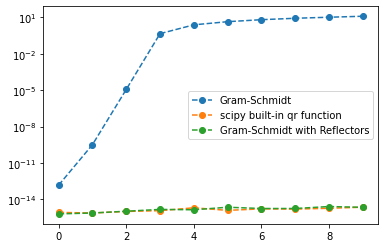

In [18]:
plt.semilogy(dev_orth_gram,'o--', label='Gram-Schmidt')
plt.semilogy(dev_orth_scipy,'o--', label='scipy built-in qr function')
plt.semilogy(dev_orth_reflectors,'o--', label='Gram-Schmidt with Reflectors')
plt.legend()

In [19]:
# least squares problem with known solution

A = np.random.randn(100,4)
A[:,3] = A[:,0]-A[:,1]+1e-10*np.random.randn(100) # almost row 1 minus row 2

x = np.array([1,1,1,0])

b = A.dot(x)

In [20]:
xNormal = np.linalg.solve(A.T.dot(A),A.T.dot(b))
xNumpy = np.linalg.lstsq(A,b, rcond = None)[0]

Q,R = my_qr1(A)
xGS = np.linalg.solve(R,Q.T.dot(b)

S,T = my_qr1(A)
                      
xGSrefl = np.linalg.solve(R,Q.T.dot(b))


SyntaxError: invalid syntax (<ipython-input-20-bc35ca2fe9d4>, line 7)

## Applications: Fitting Lines / Polynomials / Functions to Data



I did not do this, but heres some stuff for HW 3 problem 8

In [ ]:
def con_bidiag(a,b):
    n = len(a)
    # norm of b
    normB = np.max(np.abs(a)+np.abs(np.append(b,0)))
    
    row_norms = np.zeros(n)
    row_norms[n-1] = 1/np.abs(a[n-1])
    
    for i in range(n-2,-1,-1):
        row_norms[i] = (1/np.abs(a[i]))*(1+np.abs(b[i])*row_norms[i+1])
        
    normBinv = np.max(row_norms)
    
    return normB*normBinv
        

In [ ]:
n = 2000
a = np.random.randn(n)
b = np.random.randn(n-1)

In [ ]:
B = np.diag(a)+np.diag(b,1)

In [ ]:
%%timeit
np.linalg.cond(B, p=np.inf)

In [ ]:
%%timeit
con_bidiag(a,b)

****
## Sensitivity of the least squares problem

Problem: $\min_x\|Ax-b\|_2, A_{m\times n}$ has independent columns (and is tall and skinny)

Question: How sensitive ix $x$ to perturbations of $b$?

### Condition number and magnification

$\kappa(A)=\|A\|\|A^{-1}\|$ when $A$ is invertible.

$\text{maxmag} = \max_{\|x\|=1}\|Ax\|$

$\text{minmag} = \min_{\|x\|=1}\|Ax\|$

But, when $A$ is invertible, $\text{minmag} A = \frac{1}{\text{maxmag}A^{-1}}$.

So $\kappa(A) = \frac{\text{maxmag}A}{\text{minmag}A}$

least squares problem: $\min \|Ax-b\|_2$ is akin to finding the projection $y$ of $b$ into the columnspace of $A$.

Then, we need to solve $Ax = y$

In [ ]:
## Singular Value Decomposition

U, S, VT = np.linalg.svd(A)

In [ ]:
# S contains the singular values
S

In [ ]:
# condition number of $A$
S[0]/S[-1] -np.linalg.cond(A)

## Least squares problems and the SVD

### Keeping $\kappa(A)$ under control: Truncated SVD

In [ ]:
threshold = S[0]*0.01
k = np.argwhere(S<threshold)[0,0] - 1 # index of first singular value smaller than threshold

# we can truncate the SVD by taking only k columns of U, the first k singular values, and the first
# k rows of V^T

# rcond in np.linalg.solve is the threshold! when we pick None, we pick threshold = 1E-16

### Regularization
Stuff happens
****

## QR factorization with column pivoting

We found reflector matrices $Q_1,\ldots, Q_n$ such that $Q_n\ldots Q_1 A = R$, where $R$ is upper triangular. THen we can use $Q = Q_1^TQ_2^T\ldots Q_n^T$ yielding $A=QR$.

We then can solve $Rx = Q^tb$ to find solve $\min \|b-Ax\|_2$

In [ ]:
def my_qr(A,how='reflectors',mode='economic', pivoting=True,threshold=1e-16):
    'it factors a full-column rank A into Q (orthogonal) times R (upper triangular)'
    m,n = A.shape
    
    if how=='Gram-Schmidt':
        Q = A.copy()
        R = np.zeros((n,n))

        for i in range(n):
            R[0:i,i] = Q[:,0:i].T.dot(Q[:,i])
            Q[:,i] = Q[:,i] - Q[:,0:i].dot(R[0:i,i])
            R[i,i] = np.linalg.norm(Q[:,i])
            Q[:,i] = Q[:,i]/R[i,i]
        return Q,R
    elif how=='reflectors':
        R = A.copy()
        Q = np.eye(m)
        
        columnnorms = np.sum(A**2, axis =0) # squared norms of the columns of $A$
        if pivoting:
            p = np.arange(n)

        for j in range(n):
            if pivoting:
                if np.max(columnnorms[j,:])<threshold*np.linalg.norm(A,ord=1):
                    R[j:,:] = 0 
                    break
                col2swap = j + np.argmax(columnnorms[j:])
                R[:,[j,col2swap]] = R[:,[col2swap,j]]
                p[[j,col2swap]] = p[[col2swap,j]]
                columnnorms[[j,col2swap]] = columnnorms[[col2swap,j]]
            # create reflector
            x = R[j:m,j].copy()
            tau = np.sign(x[0])*np.linalg.norm(x)
            x[0] = tau + x[0]
            gamma = x[0]/tau
            x[1:len(x)] = x[1:len(x)]/x[0]
            x[0] = 1
            tau = tau

            # apply reflector to R
            R[j:m,j:n] = R[j:m,j:n] - gamma*np.outer(x,x.dot(R[j:m,j:n]))
            # apply reflector to P
            Q[j:m,:] = Q[j:m,:] - gamma*np.outer(x,x.dot(Q[j:m,:]))
            #update columnn norms
            if pivoting:
                columnnorms = columnnorms - R[j]**2
                #columnnorms = columnnorms[1:]
        if mode == 'complete':
            if pivoting:
                return Q.T, np.triu(R),p
            else:
                return Q.T, np.triu(R)
        if mode == 'economic':
            if pivoting:
                return Q.T[:,0:j], np.triu(R)[0:j],p
            else:
                return Q.T[:,0:n], np.triu(R)[0:n]

In [ ]:
A = np.random.randn(5,3)
A

In [ ]:
Q,R,P = my_qr(A, how='reflectors',mode='economic', pivoting=True)

In [ ]:
# AP = QR

np.linalg.norm(A[:,P] - Q.dot(R))

In [ ]:
R

## Ways to solve $\min\|Ax-b\|_2$

1) if $\kappa (A) >> 1$:

    QR Factorization with column pivoting
    Truncation (Based on SVD)
    Regularization

2) if $\kappa (A) > 1$:

    QR Factorization
    SVD Factorization (more accurate, more expensive)

3) if $\kappa (A) \approx 1$:

    Solve $A^TAx = A^Tb$

In [ ]:
## Cholesky factorization

def my_cholesky(A):
    m,n = A.shape
    if m!= n:
        print('Warning: A must be a square matrix')
    R = np.zeros((n,n))
    
    for i in range(n):
        R[i,i] = A[i,i]-R[0:i,i].dot(R[0:i,i])
        if R[i,i]<0:
            print('Warning: A must be a positive definite matrix')
            return
        R[i,i]=np.sqrt(R[i,i])
        for j in range(i+1,n):
            R[i,j]=(A[i,j]-R[0:i,i].dot(R[0:i,j]))/R[i,i]
    return R

In [ ]:
A = np.random.randn(5,3)
R=my_cholesky(A)

In [ ]:
A = np.random.randn(5,3)
A = A.T.dot(A)
R=my_cholesky(A)

In [ ]:
R

In [ ]:
np.linalg.norm(A-R.T.dot(R))

## Cholesky

Using Cholesky is faster than using QR or SVD factorizations.

However, it can only be used when $\kappa(A)\approx 1$.

Theorem: $\kappa (A^TA) = (\kappa (A))^2$

proof: Look at SVD of $A$ and then $A^TA$.